# Chapter 165 — Matrix Transformations Visualization

> **Prerequisites:** Linear transformations *(ch164)*, matrix multiplication *(ch154)*
> **You will learn:**
> - How to visualize the effect of any 2D matrix on the plane
> - Composition of transformations as chained matrices
> - The role of determinant sign in orientation
> - A visualization tool you can reuse throughout Part VI
>
> **Environment:** Python 3.x, numpy, matplotlib

C:\Users\user\AppData\Local\Temp\ipykernel_11216\2718893563.py:30: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])
C:\Users\user\AppData\Local\Temp\ipykernel_11216\2718893563.py:65: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_11216\2718893563.py:65: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


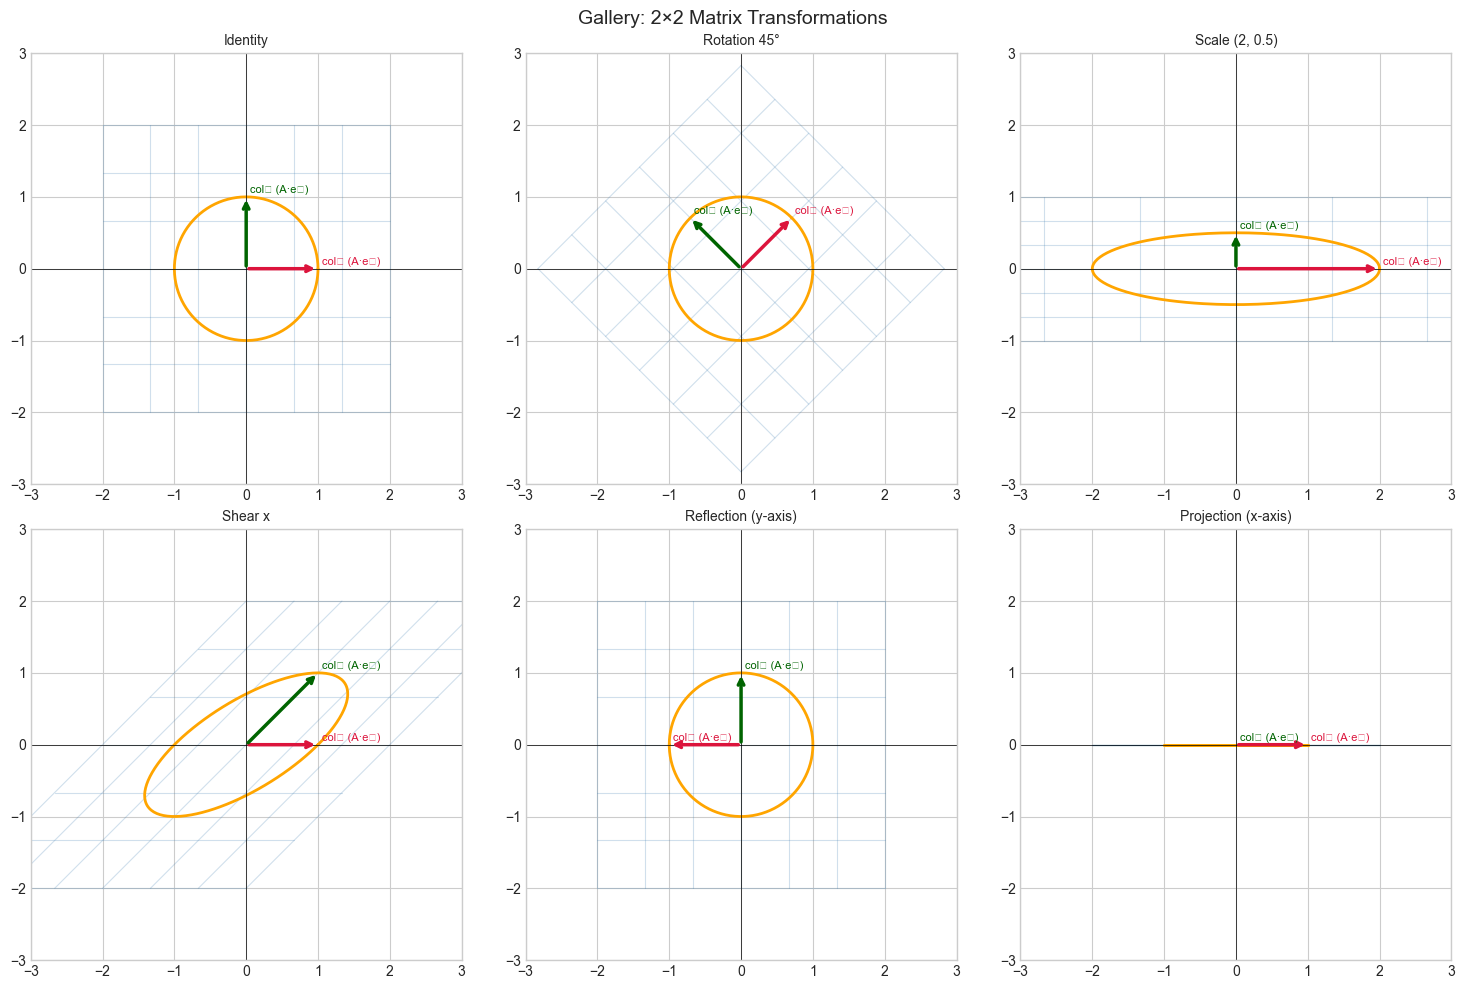

In [1]:
# --- Visualization Tool: Any 2×2 matrix on the plane ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def visualize_transform(A, ax=None, n_grid=6, title=None):
    """
    Visualize the effect of 2x2 matrix A on the plane.
    Shows: grid lines, a test circle, and the column vectors.

    Args:
        A: 2x2 numpy array
        ax: matplotlib axis (creates new if None)
        n_grid: number of grid lines in each direction
        title: plot title (auto-generates from matrix if None)
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6,6))
    lines = np.linspace(-2, 2, n_grid+1)
    # Grid lines
    for v in lines:
        for pts in [
            np.array([[t, v] for t in np.linspace(-2,2,50)]).T,
            np.array([[v, t] for t in np.linspace(-2,2,50)]).T,
        ]:
            tr = A @ pts
            ax.plot(tr[0], tr[1], 'steelblue', alpha=0.25, lw=0.8)
    # Circle
    t = np.linspace(0, 2*np.pi, 200)
    circle = np.row_stack([np.cos(t), np.sin(t)])
    tc = A @ circle
    ax.plot(tc[0], tc[1], 'orange', lw=2, label='unit circle')
    # Column vectors (basis images)
    colors = ['crimson', 'darkgreen']
    labels = ['col₁ (A·e₁)', 'col₂ (A·e₂)']
    for j, (col, color, label) in enumerate(zip(A.T, colors, labels)):
        ax.annotate('', xy=col, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(col[0]+0.05, col[1]+0.05, label, color=color, fontsize=8)
    det = np.linalg.det(A)
    if title is None:
        title = f"det={det:.2f}"
    ax.set_title(title, fontsize=10)
    lim = max(3, np.max(np.abs(A)) * 1.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    return ax

# Gallery of transformations
theta = np.pi / 4
transforms = {
    'Identity':          np.eye(2),
    'Rotation 45°':     np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]]),
    'Scale (2, 0.5)':   np.array([[2,0],[0,0.5]]),
    'Shear x':          np.array([[1,1],[0,1]]),
    'Reflection (y-axis)': np.array([[-1,0],[0,1]]),
    'Projection (x-axis)': np.array([[1,0],[0,0]]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (title, A) in zip(axes.flat, transforms.items()):
    visualize_transform(A, ax=ax, title=title)

plt.suptitle('Gallery: 2×2 Matrix Transformations', fontsize=14)
plt.tight_layout(); plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_11216\2718893563.py:30: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])
C:\Users\user\AppData\Local\Temp\ipykernel_11216\156634907.py:21: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_11216\156634907.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


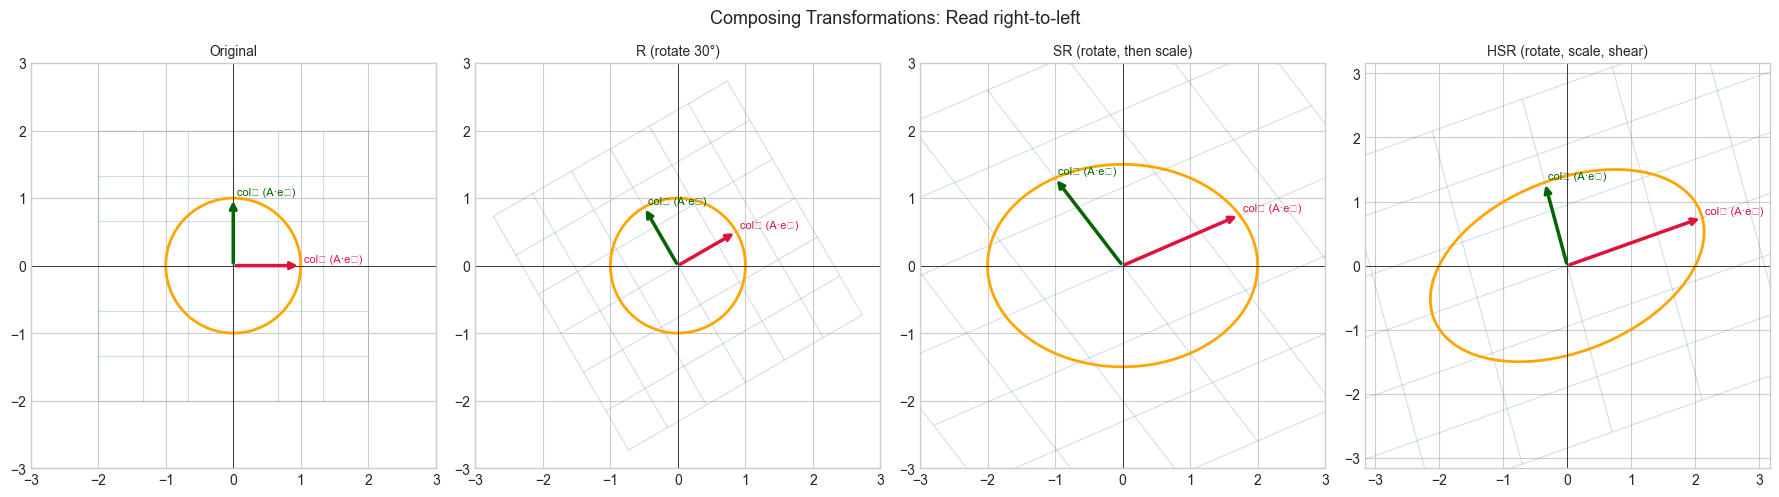

det(H) = 1.000
det(S) = 3.000
det(R) = 1.000
det(HSR) = 3.000
det(H)*det(S)*det(R) = 3.000


In [2]:
# --- Composition: Applying multiple transformations ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

theta = np.pi / 6  # 30 degrees
R = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])  # rotate
S = np.array([[2.,0.],[0.,1.5]])   # scale
H = np.array([[1.,0.5],[0.,1.]])   # horizontal shear

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (M, title) in zip(axes, [
    (np.eye(2),   'Original'),
    (R,           'R (rotate 30°)'),
    (S @ R,       'SR (rotate, then scale)'),
    (H @ S @ R,   'HSR (rotate, scale, shear)'),
]):
    visualize_transform(M, ax=ax, title=title)

plt.suptitle('Composing Transformations: Read right-to-left', fontsize=13)
plt.tight_layout(); plt.show()

# Verify that det(ABC) = det(A)*det(B)*det(C)
print(f"det(H) = {np.linalg.det(H):.3f}")
print(f"det(S) = {np.linalg.det(S):.3f}")
print(f"det(R) = {np.linalg.det(R):.3f}")
print(f"det(HSR) = {np.linalg.det(H@S@R):.3f}")
print(f"det(H)*det(S)*det(R) = {np.linalg.det(H)*np.linalg.det(S)*np.linalg.det(R):.3f}")

---

## 7. Exercises

**Easy 1.** Use `visualize_transform` on `[[0,1],[1,0]]`. What transformation is this? What is the determinant?

**Easy 2.** What happens to the unit circle when you apply a matrix with det=0? Why?

**Medium 1.** Create an animation (using `FuncAnimation`) that interpolates between the identity matrix and a rotation by 90°.

**Medium 2.** Visualize the effect of `A^k` for k=1..5 for a matrix `A=[[0.9,-0.1],[0.1,0.9]]`. What happens to the grid as k increases?

**Hard.** Implement `visualize_3d_transform(A)` for 3×3 matrices using matplotlib's 3D plotting. Show the unit sphere under A using `ax.plot_surface`.

---

## 9. Chapter Summary & Connections

- Every 2×2 matrix defines a linear warp of the plane: grid lines stay parallel (no curves).
- Determinant sign tracks orientation; magnitude tracks area scaling.
- `visualize_transform` is your debugging tool for Part VI — whenever a matrix result looks wrong, visualize it.

**Forward connections:**
- In ch166 (Rotations via Matrices), we derive rotation matrices analytically.
- In ch169 (Eigenvectors Intuition), eigenvectors are the special directions not rotated by A — visible in the visualizer as directions the grid lines don't turn.